In [35]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, root_mean_squared_error, r2_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

In [17]:
df = pd.read_csv("Titanic-Dataset.csv")

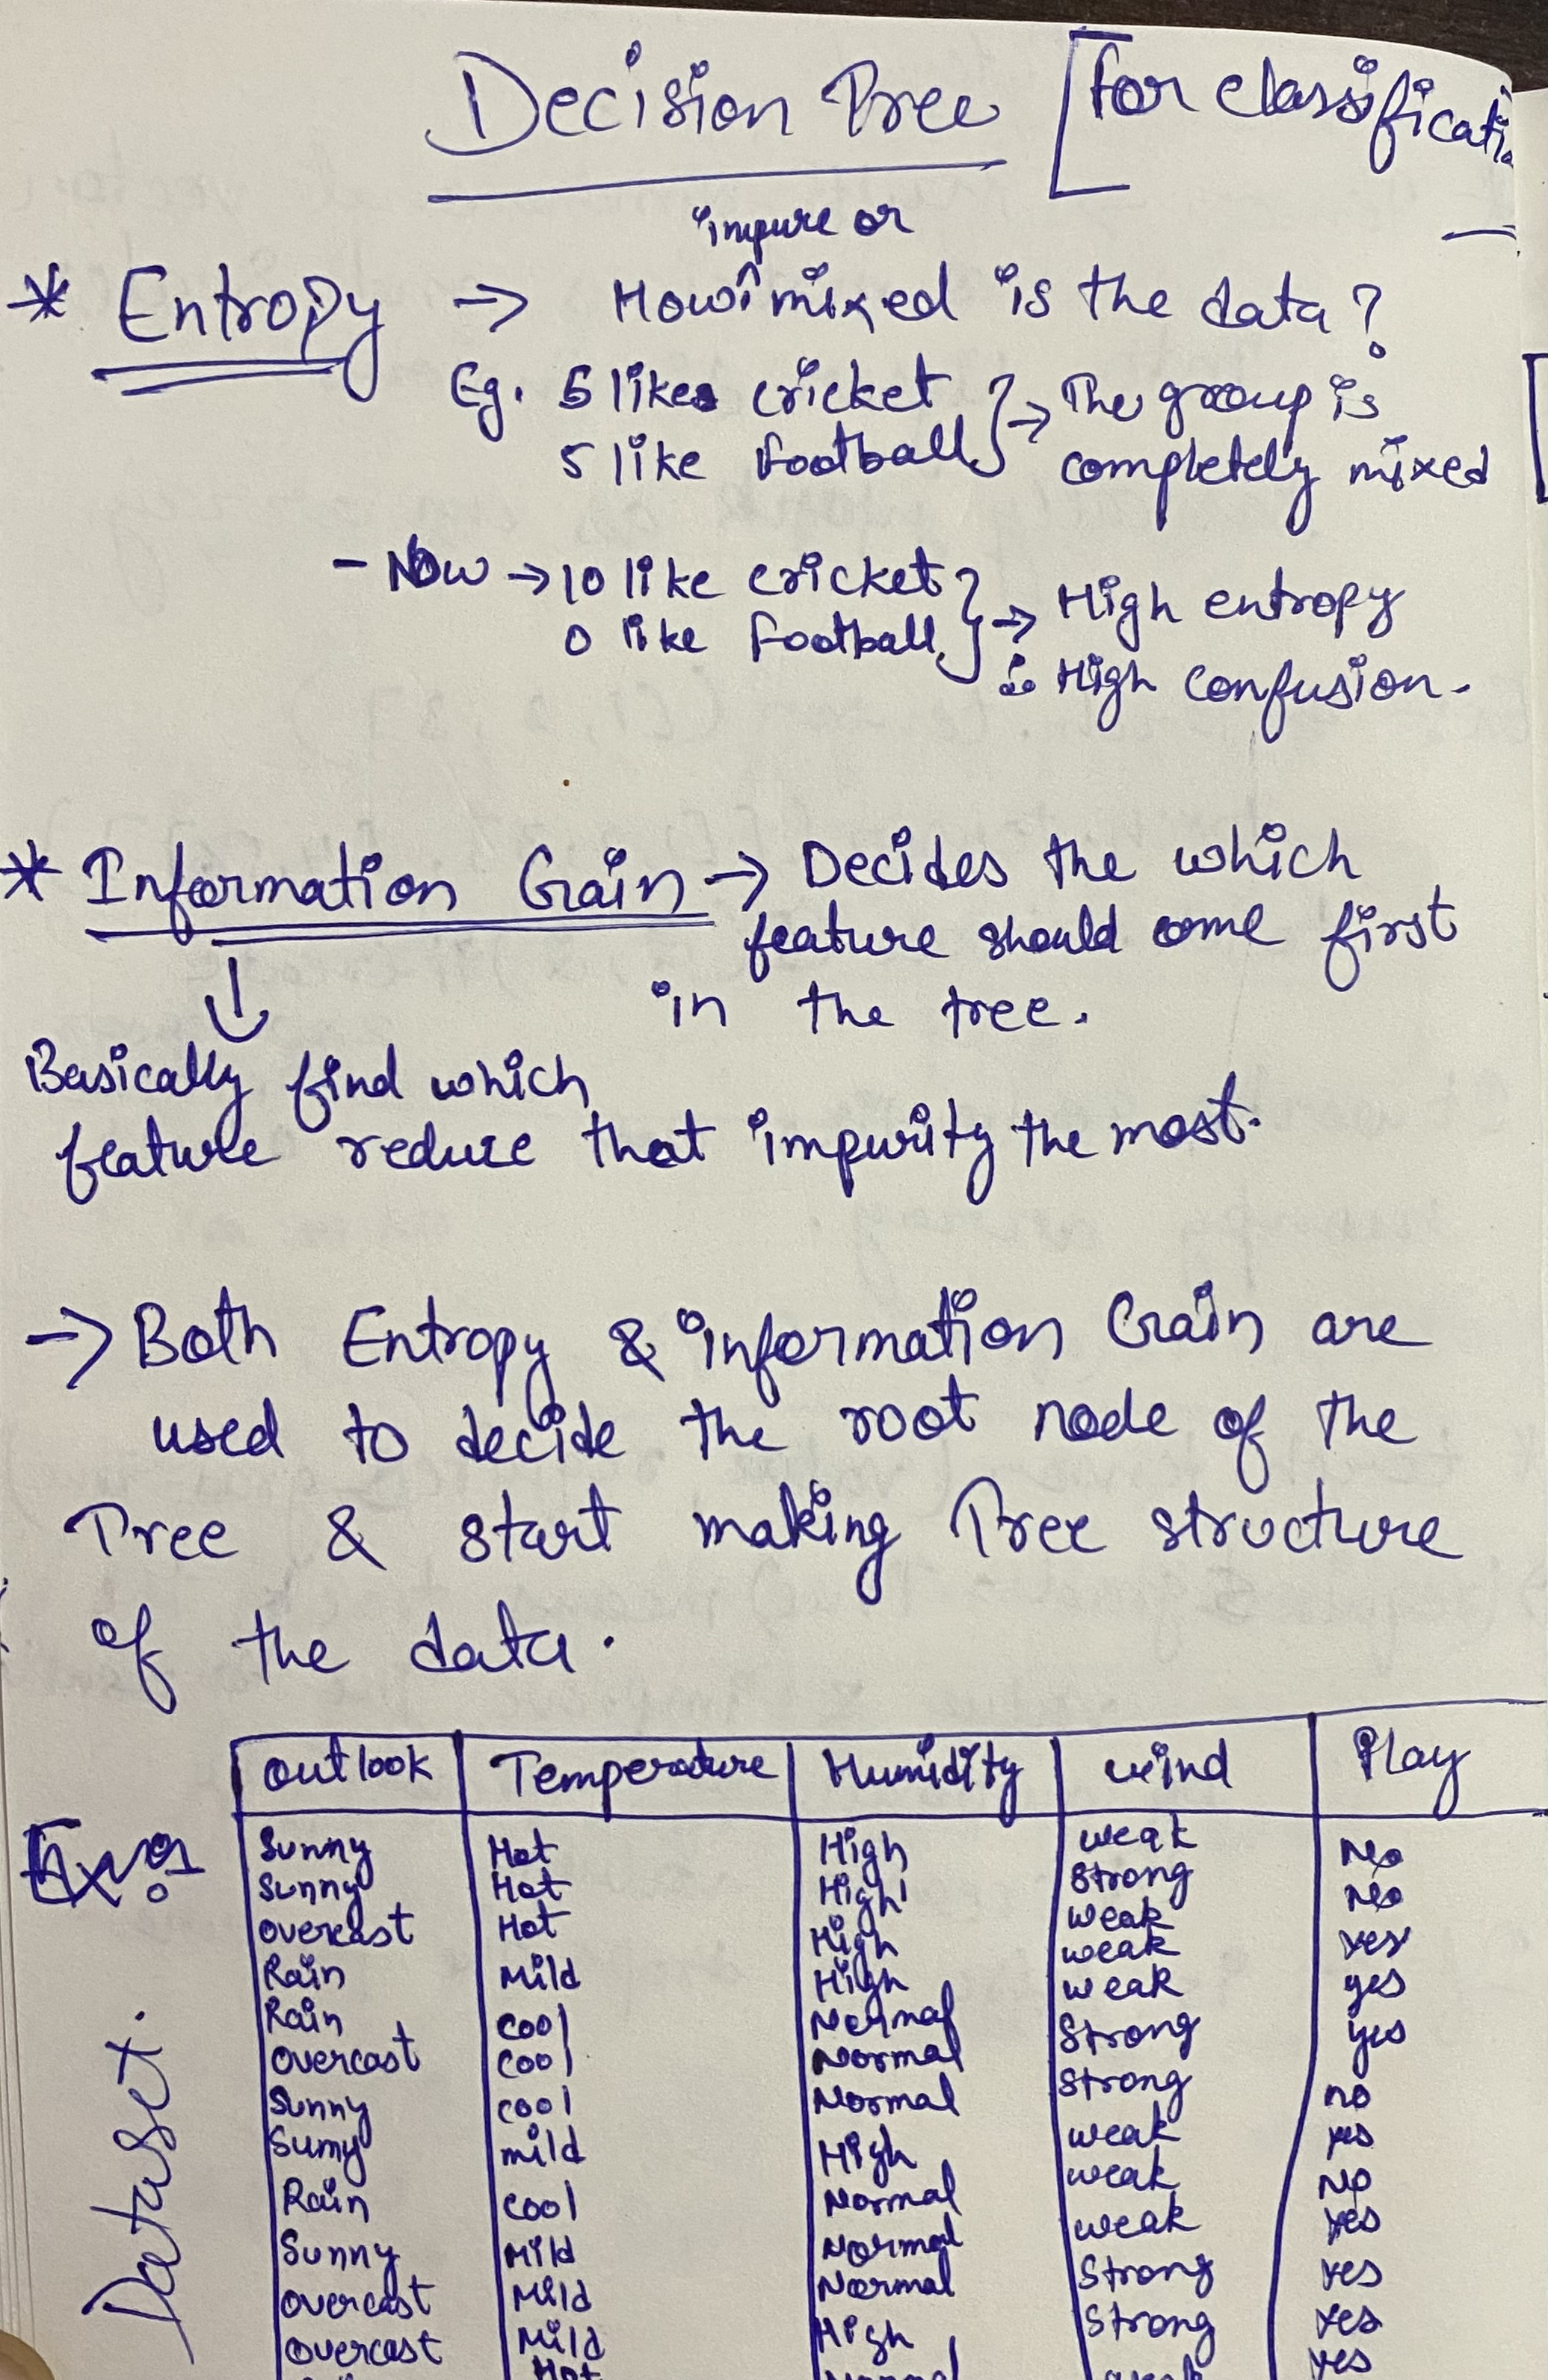
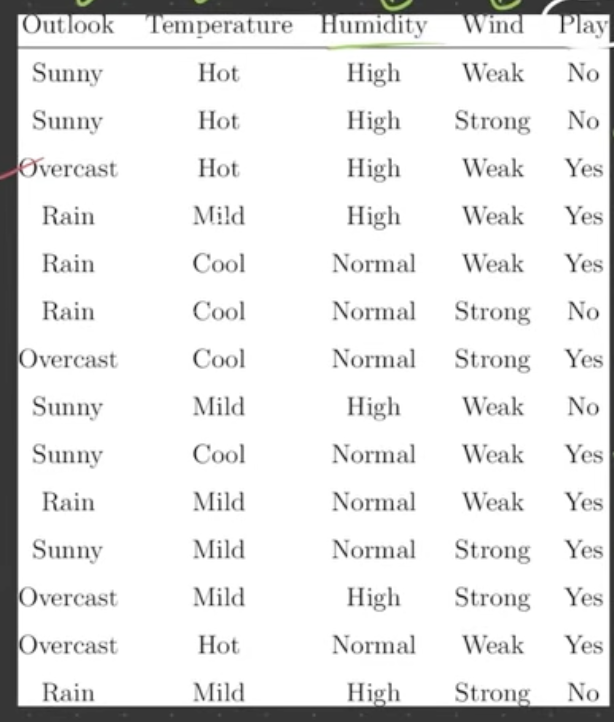
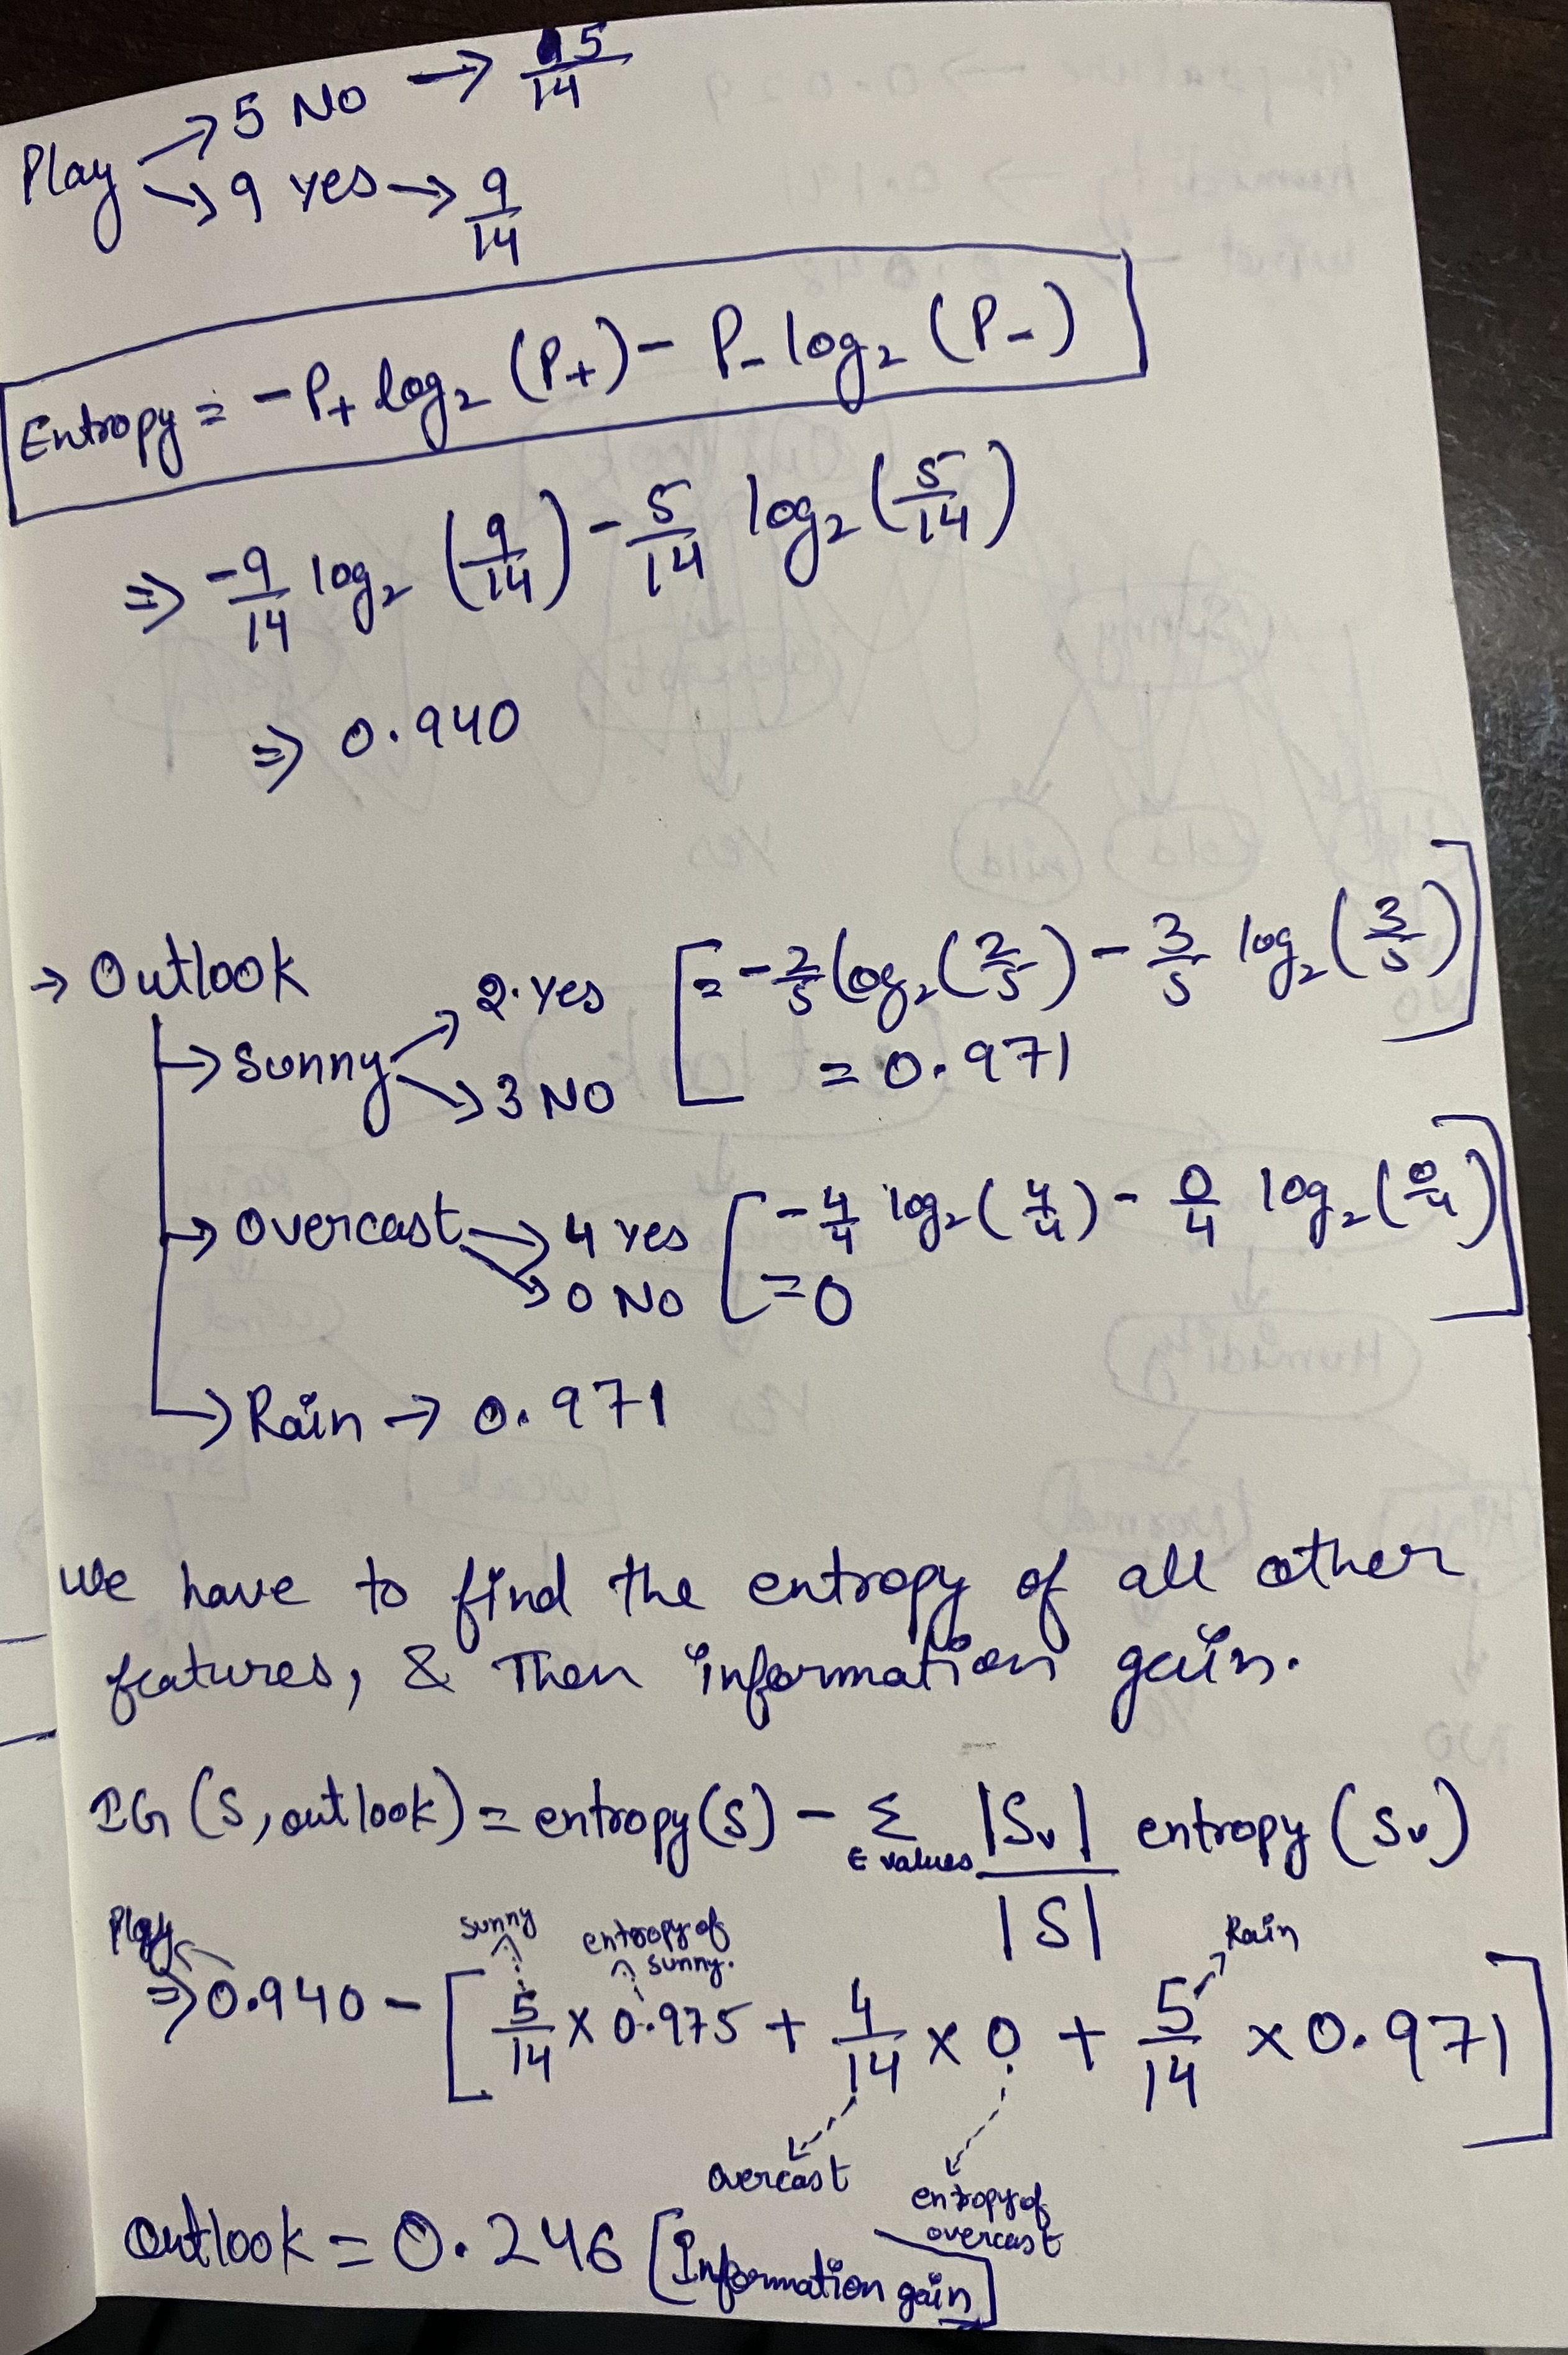
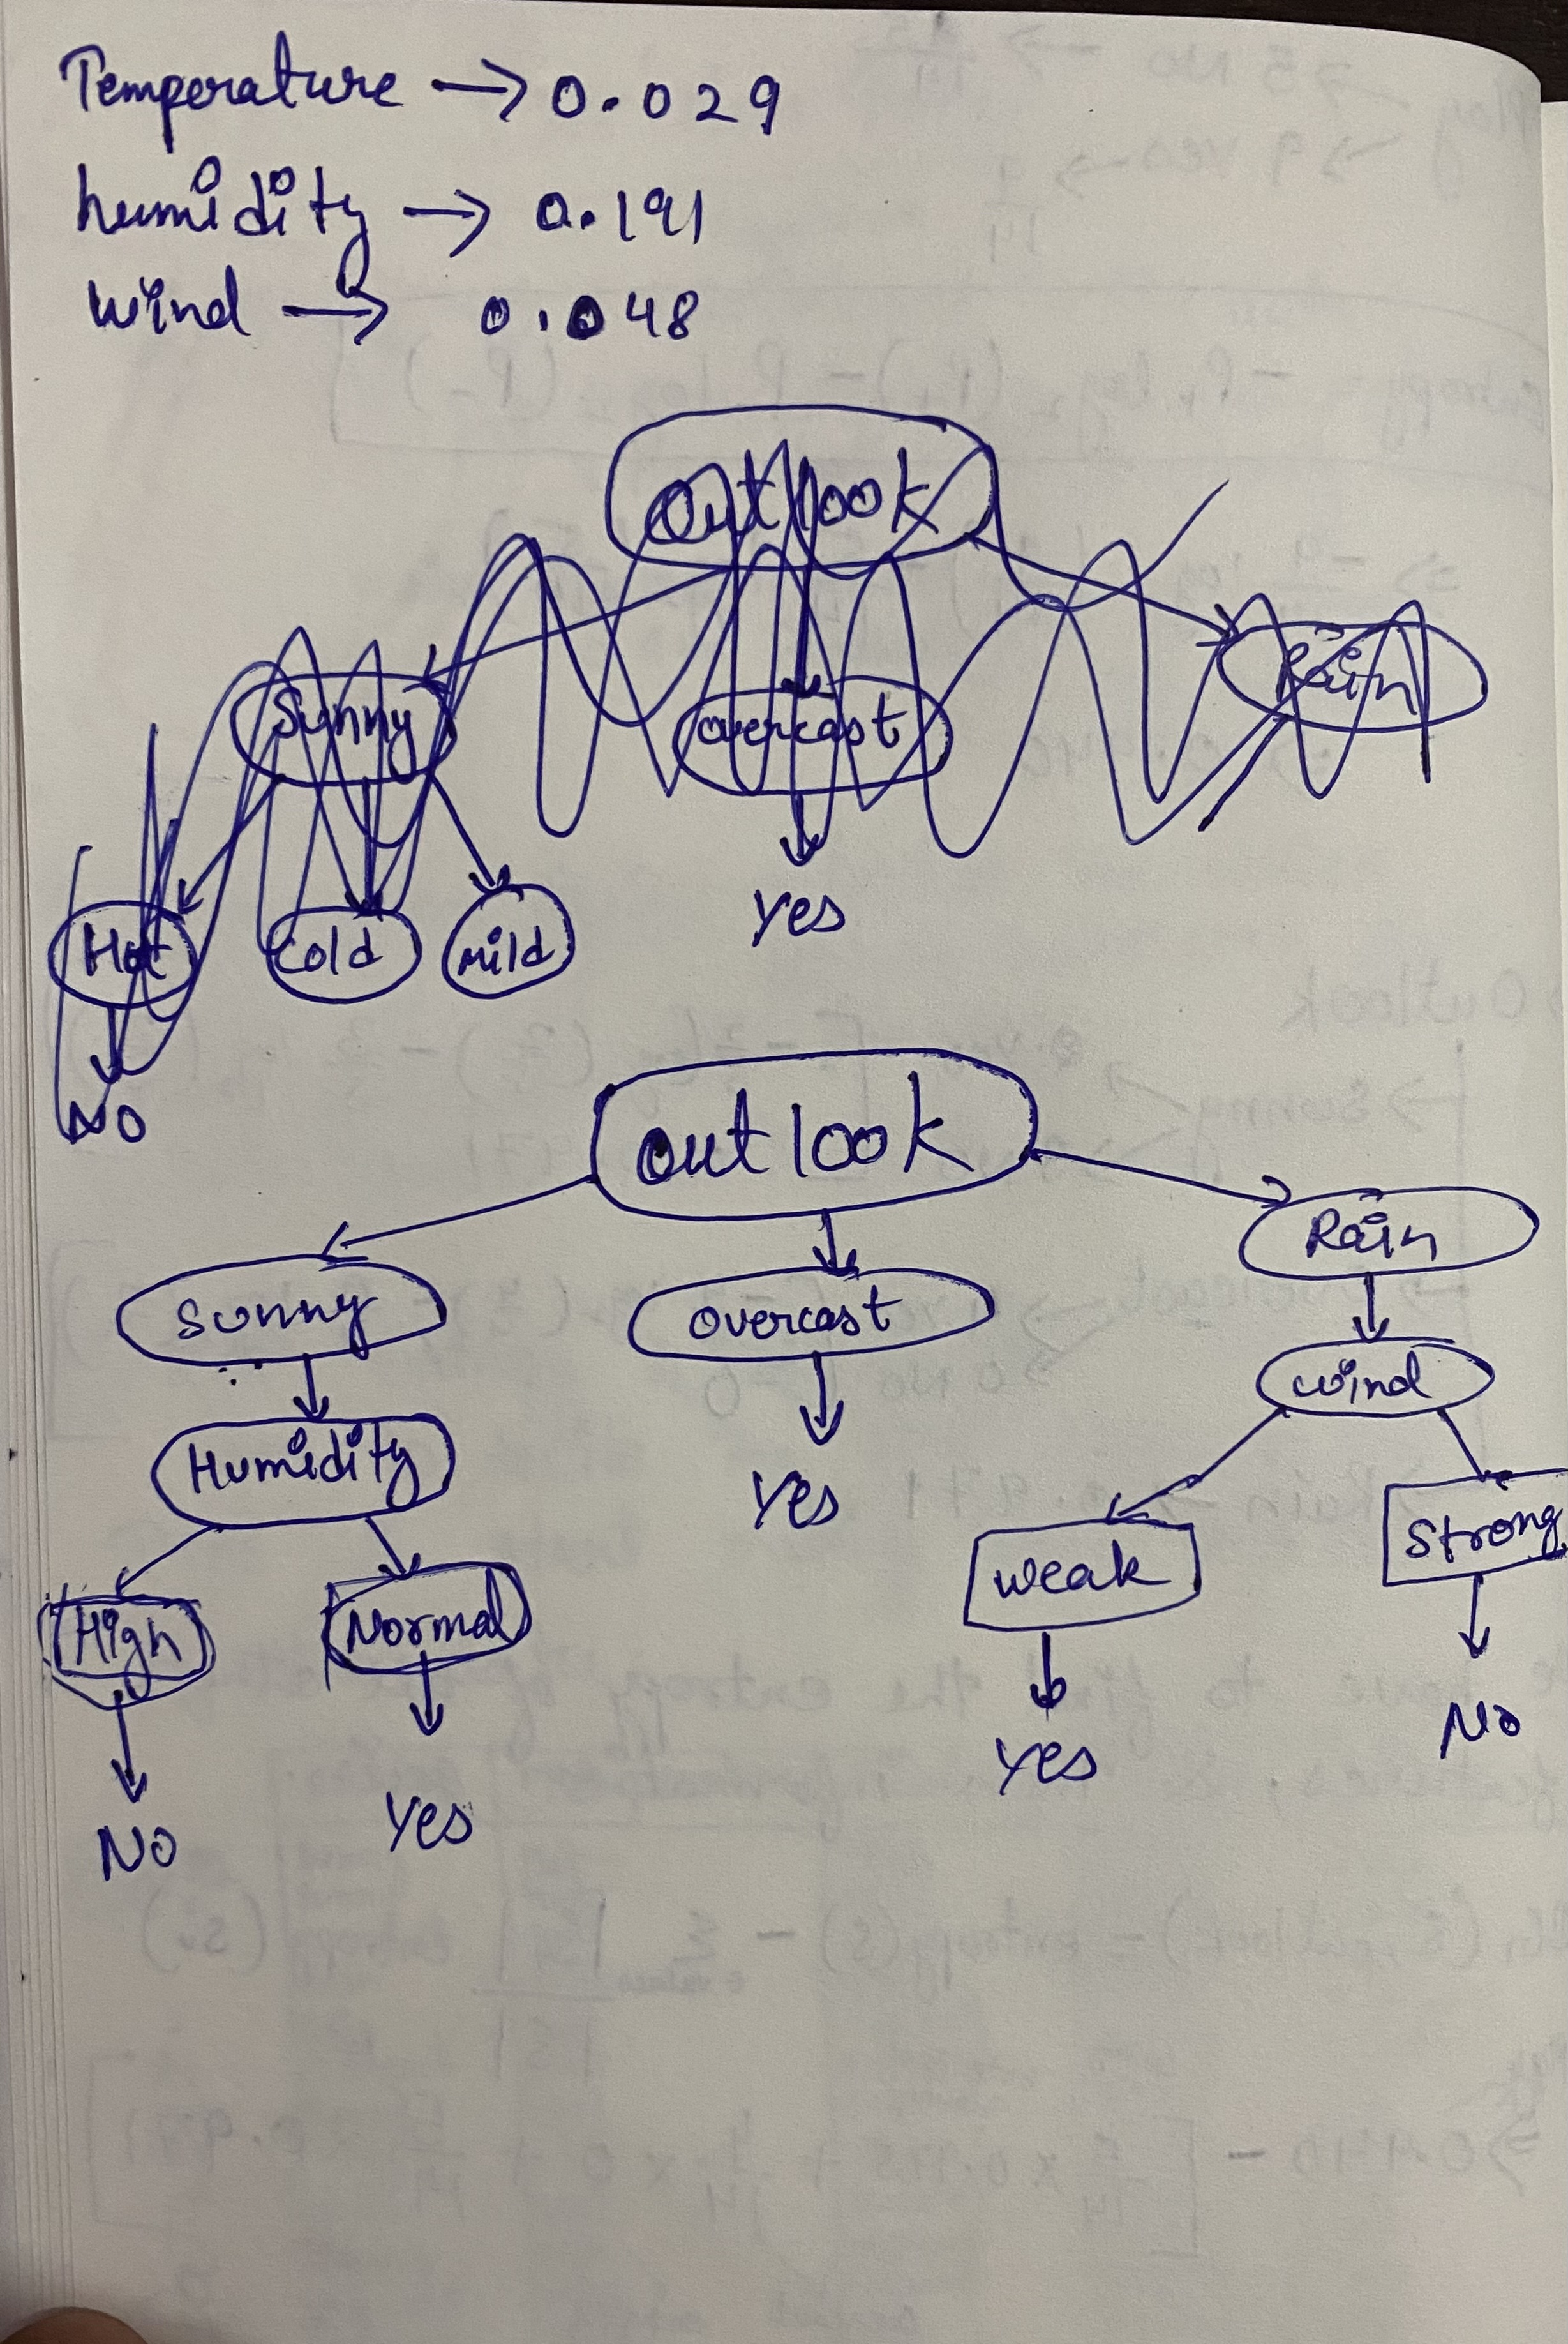

In [18]:

x = df.drop(columns=['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin'])

label = LabelEncoder()
x['Embarked'] = label.fit_transform(x['Embarked']) 
x['Sex'] = label.fit_transform(x['Sex'])

impute = SimpleImputer(strategy="median")
x = impute.fit_transform(x)

y = df['Survived']
scale = StandardScaler()
x = scale.fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split(x,y, random_state=76, test_size=0.2 )

In [19]:
model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [20]:
y_pred = model.predict(x_test)

In [21]:
accuracy_score(y_test, y_pred)

0.8491620111731844

In [22]:
recall_score(y_test, y_pred)

0.8235294117647058

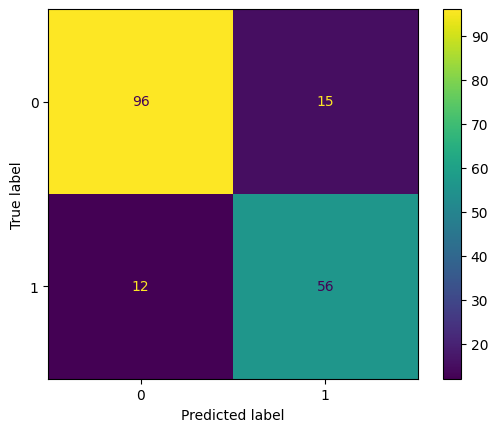

In [23]:
con_mat = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(con_mat).plot()

In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88       111
           1       0.79      0.82      0.81        68

    accuracy                           0.85       179
   macro avg       0.84      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179



# Regression

In [25]:
df2 = pd.read_csv("housing.csv")

In [26]:
def build_pipeline(num_att, cat_att): 

    cat_pipe = Pipeline([
        ("OneHot", OneHotEncoder(handle_unknown="ignore"))
    ])
    
    num_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("stand", StandardScaler())
    ])

    full_pipe = ColumnTransformer([
        ("cat", cat_pipe, cat_att),
        ("num", num_pipe, num_att) 
        
    ])
    return full_pipe

In [27]:
x = df2.drop('median_house_value', axis=1) 
y = df2['median_house_value']

num_att = x.drop('ocean_proximity', axis=1).columns.to_list()
cat_att = ['ocean_proximity'] 


pipeline = build_pipeline(num_att, cat_att)
x_transformed = pipeline.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(x_transformed,y, random_state=42, test_size=0.2)

In [28]:
reg_model = DecisionTreeRegressor(random_state=42)
reg_model.fit(x_train, y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [30]:
y_pred_reg = reg_model.predict(x_test)

In [33]:
r2_score(y_test, y_pred_reg)

0.6414836906675316

In [36]:
root_mean_squared_error(y_test, y_pred_reg)

68542.17611041089

In [37]:
y_test.describe()

count      4128.000000
mean     205500.309593
std      114486.964288
min       14999.000000
25%      119275.000000
50%      178650.000000
75%      263000.000000
max      500001.000000
Name: median_house_value, dtype: float64